In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

Saving NYC Harbor Water.csv to NYC Harbor Water.csv


In [ ]:
#Load data set
df_HW = pd.read_csv("NYC Harbor Water.csv")

/tmp/ipykernel_50587/1144363260.py:2: DtypeWarning: Columns (5,6,7,10,11,12,13,26,27,36,38,39,41,51,52,53,54,57,60,63,64,65,67,68,70,76,77,79,94,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df_HW = pd.read_csv("NYC Harbor Water.csv")


In [ ]:
row_count = len(df_HW)
row_count = df_HW.shape[0]
print(f"Total rows: {row_count}")

Total rows: 98288


In [ ]:
#Display first 5 rows
df_HW.head(5)

,sample_date,sampling_location,duplicate_sample,sample_time,weather_condition_dry_or_wet,top_sample_temperature_c,bottom_sample_temperature_c,site_actual_depth_ft,top_sample_depth_ft,bottom_sample_depth_ft,...,oakwood_bod_top_sample_mg_l,oakwood_bod_bottom_sample_mg_l,oakwood_total_suspended_solid_top_sample_mg_l,oakwood_total_suspended_solid_bottom_sample_mg_l,top_turbidity_nephelometric_turbidity_units,bottom_turbidity_ysi_nephelometric_turbidity_units,sampling_comment,long,lat,type
0,1963-07-01T00:00:00.000,H5,NaN,9:40 AM,NaN,23.9,22.8,22.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.935832,40.787777,Permanent
1,2017-08-28T00:00:00.000,E8,NaN,14:33,Dry,23.02,22.77,82.0,3.0,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.78367,40.800500,Permanent
2,1968-08-26T00:00:00.000,E5,NaN,12:41 PM,NaN,23.3,23.3,NaN,NaN,NaN,...,2.2,3.5,NaN,NaN,NaN,NaN,NaN,-73.886111,40.800833,Permanent
3,1909-09-07T00:00:00.000,x804_1909,NaN,2:15 PM,NaN,21,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.908333,40.931667,Permanent
4,2009-07-28T00:00:00.000,J8,NaN,13:34,W,25.2,24.7,22.0,3.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.64303,-73.850140,Permanent


In [ ]:
#Display all column names
df_HW.columns

Index(['sample_date', 'sampling_location', 'duplicate_sample', 'sample_time',
       'weather_condition_dry_or_wet', 'top_sample_temperature_c',
       'bottom_sample_temperature_c', 'site_actual_depth_ft',
       'top_sample_depth_ft', 'bottom_sample_depth_ft', 'top_salinity_psu',
       'bottom_salinity_psu', 'top_conductivity_s_m',
       'bottom_conductivity_s_m',
       'ctd_conductivity_temperature_depth_profiler_top_dissolved_oxygen_mg_l',
       'ctd_conductivity_temperature_depth_profiler_bottom_dissolved_oxygen_mg_l',
       'percentage_o2_saturation_top_sample',
       'percentage_o2_saturation_bottom_sample',
       'light_trans_transparency_top_sample',
       'light_trans_transparency_bottom_sample', 'top_sigma_t_kg_m3',
       'bottom_sigma_t_kg_m3', 'top_fluorometer_mg_m3',
       'bottom_fluorometer_mg_m3',
       'ctd_conductivity_temperature_depth_profiler_ph_top_sample',
       'ctd_conductivity_temperature_depth_profiler_ph_bottom_sample',
       'top_sample_photos

In [ ]:
#Dispaly all columns data types
df_HW.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98288 entries, 0 to 98287
Data columns (total 100 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   sample_date                                                                    98288 non-null  object 
 1   sampling_location                                                              98288 non-null  object 
 2   duplicate_sample                                                               404 non-null    object 
 3   sample_time                                                                    94753 non-null  object 
 4   weather_condition_dry_or_wet                                                   38603 non-null  object 
 5   top_sample_temperature_c                                                       78242 non-null  object 
 6   bottom_sample_tempera

In [ ]:
#Filter Data - Compare water pH between top vs. bottom)
df_filter = df_HW[df_HW['top_ph'].isin(['T', 'B'])]

In [ ]:
df_filter = df_HW.copy()

In [ ]:
#Count total arrest at Queens(Q) and Manhattan (M)

df_filter['top_ph'].value_counts()

,count
top_ph,


In [ ]:
df_filter['top_bottom_coliform_cells_100_ml'].value_counts()

,count
top_bottom_coliform_cells_100_ml,


In [ ]:
#Count total records by PREP_RACE

df_filter ['top_ph'].value_counts()

,count
top_ph,


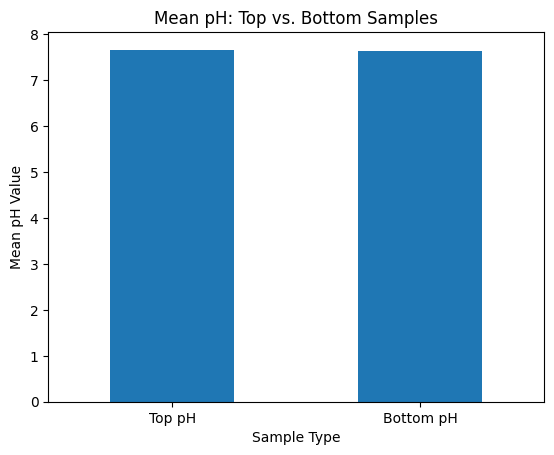

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'top_ph' and 'bottom_ph' to numeric, coercing errors
df_filter['top_ph'] = pd.to_numeric(df_filter['top_ph'], errors='coerce')
df_filter['bottom_ph'] = pd.to_numeric(df_filter['bottom_ph'], errors='coerce')

# Compare pH: Top vs. Bottom

# Calculate mean pH for top and bottom samples
mean_ph_top = df_filter['top_ph'].mean()
mean_ph_bottom = df_filter['bottom_ph'].mean()

# Create a Series for plotting
ph_comparison = pd.Series({
    'Top pH': mean_ph_top,
    'Bottom pH': mean_ph_bottom
})

ph_comparison.plot(kind='bar')
plt.title("Mean pH: Top vs. Bottom Samples")
plt.xlabel("Sample Type")
plt.ylabel("Mean pH Value")
plt.xticks(rotation=0)
plt.show()

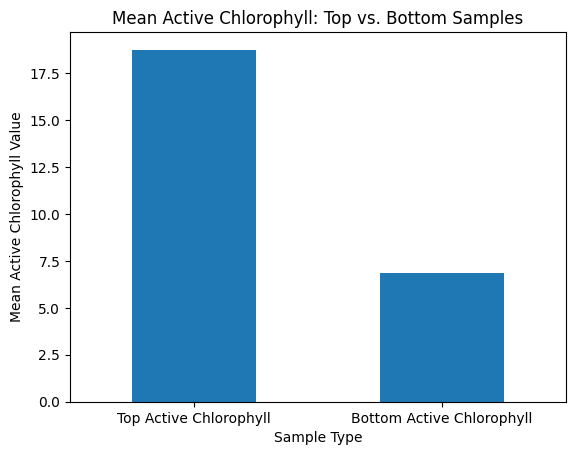

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'active chlorophyll' columns to numeric, coercing errors
df_filter['top_active_chlorophyll'] = pd.to_numeric(df_filter['top_active_chlorophyll_a_g_l'], errors='coerce')
df_filter['bottom_active_chlorophyll'] = pd.to_numeric(df_filter['bottom_active_chlorophyll_a_g_l'], errors='coerce')

# Compare Active Chlorophyll: Top vs. Bottom

# Calculate mean Active Chlorophyll for top and bottom samples
mean_top_active_chlorophyll = df_filter['top_active_chlorophyll'].mean()
mean_bottom_active_chlorophyll = df_filter['bottom_active_chlorophyll'].mean()

# Create a Series for plotting
ph_comparison = pd.Series({
    'Top Active Chlorophyll': mean_top_active_chlorophyll,
    'Bottom Active Chlorophyll': mean_bottom_active_chlorophyll
})

ph_comparison.plot(kind='bar')
plt.title("Mean Active Chlorophyll: Top vs. Bottom Samples")
plt.xlabel("Sample Type")
plt.ylabel("Mean Active Chlorophyll Value")
plt.xticks(rotation=0)
plt.show()

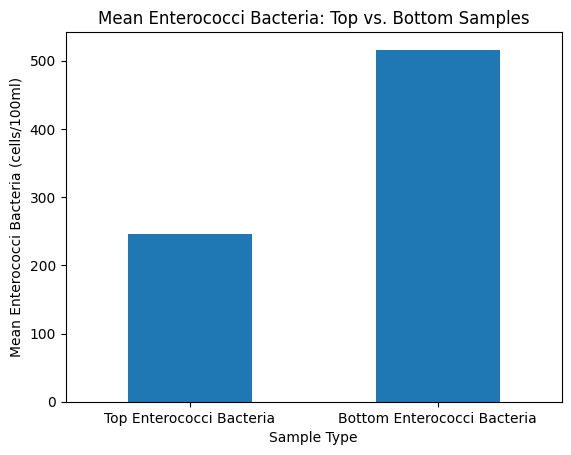

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'enterococci bacteria' columns to numeric, coercing errors
df_filter['top_enterococci_bacteria_cells_100ml'] = pd.to_numeric(df_filter['top_enterococci_bacteria_cells_100ml'], errors='coerce')
df_filter['bottom_enterococci_bacteria_cells_100ml'] = pd.to_numeric(df_filter['bottom_enterococci_bacteria_cells_100ml'], errors='coerce')

# Compare Enterococci Bacteria: Top vs. Bottom

# Calculate mean for top and bottom samples
mean_ph_top = df_filter['top_enterococci_bacteria_cells_100ml'].mean()
mean_ph_bottom = df_filter['bottom_enterococci_bacteria_cells_100ml'].mean()

# Create a Series for plotting
ph_comparison = pd.Series({
    'Top Enterococci Bacteria': mean_ph_top,
    'Bottom Enterococci Bacteria': mean_ph_bottom
})

ph_comparison.plot(kind='bar')
plt.title("Mean Enterococci Bacteria: Top vs. Bottom Samples")
plt.xlabel("Sample Type")
plt.ylabel("Mean Enterococci Bacteria (cells/100ml)")
plt.xticks(rotation=0)
plt.show()

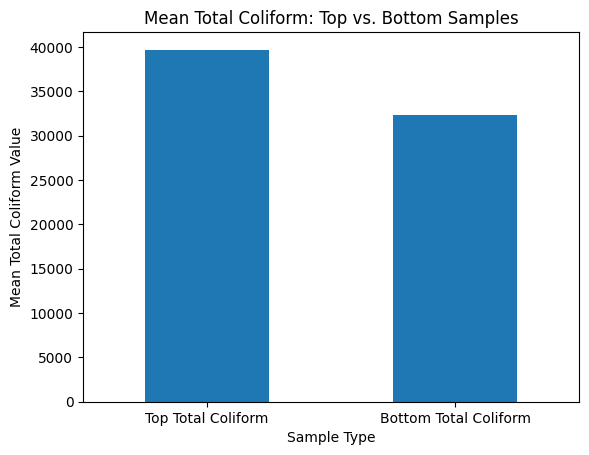

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'total coliform' columns to numeric, coercing errors
df_filter['top_total_coliform'] = pd.to_numeric(df_filter['top_total_coliform_cells_100_ml'], errors='coerce')
df_filter['bottom_total_coliform'] = pd.to_numeric(df_filter['top_bottom_coliform_cells_100_ml'], errors='coerce')

# Compare Total Coliform: Top vs. Bottom

# Calculate mean Total Coliform for top and bottom samples
mean_total_coliform_top = df_filter['top_total_coliform'].mean()
mean_total_coliform_bottom = df_filter['bottom_total_coliform'].mean()

# Create a Series for plotting
ph_comparison = pd.Series({
    'Top Total Coliform': mean_total_coliform_top,
    'Bottom Total Coliform': mean_total_coliform_bottom
})

ph_comparison.plot(kind='bar')
plt.title("Mean Total Coliform: Top vs. Bottom Samples")
plt.xlabel("Sample Type")
plt.ylabel("Mean Total Coliform Value")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#df_HW = df_HW[
#    (df_HW["sample location"] == "T") &
#    (df_HW["weather_condtion_dry_or_wet"] == "B")
#].copy()

In [ ]:
df_HW= df_HW.dropna(subset=["lat", "long"])

In [ ]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(df_HW,
    geometry=gpd.points_from_xy(df_HW["long"], df_HW["lat"]),
    crs="EPSG:4326")

ValueError: aspect must be finite and positive 

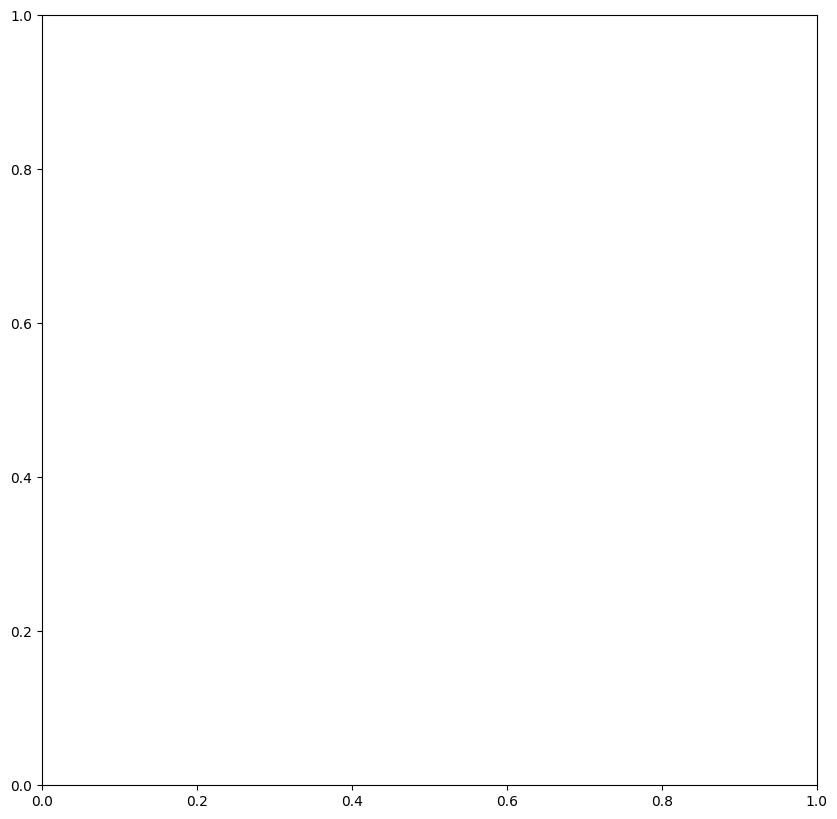

In [ ]:
gdf.plot(markersize=1, figsize=(10, 10))

In [ ]:
display(df_filter.head())

,sample_date,sampling_location,duplicate_sample,sample_time,weather_condition_dry_or_wet,top_sample_temperature_c,bottom_sample_temperature_c,site_actual_depth_ft,top_sample_depth_ft,bottom_sample_depth_ft,...,sampling_comment,long,lat,type,top_active_chlorophyll,bottom_top_active_chlorophyll,top_total_coliform,bottom_top_total_coliform,bottom_active_chlorophyll,bottom_total_coliform
0,1963-07-01T00:00:00.000,H5,NaN,9:40 AM,NaN,23.9,22.8,22.0,NaN,NaN,...,NaN,-73.935832,40.787777,Permanent,NaN,NaN,1100.0,NaN,NaN,1100.0
1,2017-08-28T00:00:00.000,E8,NaN,14:33,Dry,23.02,22.77,82.0,3.0,79.0,...,NaN,-73.78367,40.800500,Permanent,4.38,7.39,NaN,7.39,NaN,NaN
2,1968-08-26T00:00:00.000,E5,NaN,12:41 PM,NaN,23.3,23.3,NaN,NaN,NaN,...,NaN,-73.886111,40.800833,Permanent,NaN,NaN,110000.0,NaN,NaN,79000.0
3,1909-09-07T00:00:00.000,x804_1909,NaN,2:15 PM,NaN,21,NaN,NaN,1.0,NaN,...,NaN,-73.908333,40.931667,Permanent,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-07-28T00:00:00.000,J8,NaN,13:34,W,25.2,24.7,22.0,3.0,16.0,...,NaN,40.64303,-73.850140,Permanent,33.00,7.79,NaN,7.79,NaN,NaN
